In [4]:
!pip3 install ag2 python-dotenv --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.7 MB/s eta 0:00:00


In [5]:
# Import necessary modules
import os
from dotenv import load_dotenv
from autogen import ConversableAgent, AssistantAgent, UserProxyAgent, GroupChat, GroupChatManager
from autogen.llm_config import LLMConfig
import json
import time
import random

# Load environment variables
load_dotenv()

print("AG2 modules imported successfully!")

/opt/homebrew/lib/python3.13/site-packages/pydantic/plugin/_loader.py:50: UserWarning: ImportError while loading the `logfire-plugin` Pydantic plugin, this plugin will not be installed.

ImportError("cannot import name 'ReadableLogRecord' from 'opentelemetry.sdk._logs' (/opt/homebrew/lib/python3.13/site-packages/opentelemetry/sdk/_logs/__init__.py)")
  warnings.warn(


AG2 modules imported successfully!


In [6]:
import logging

# Suppress API key format warning
logging.getLogger("autogen.oai.client").setLevel(logging.ERROR)

In [11]:
# LLM configuration (API key will be taken from environment variable)
llm_config = {
    "config_list": [
        {
            "api_type": "openai",
            "model": "Qwen/Qwen3.5-397B-A17B:novita",  # or your HF model/provider
            "api_key": os.getenv("HUGGINGFACEHUB_API_TOKEN") or os.getenv("HF_TOKEN"),
            "base_url": os.getenv("HUGGINGFACE_BASE_URL", "https://router.huggingface.co/v1"),
        }
    ],
    "temperature": 0,
    "timeout": 120,
}

### Introduction to Agent Concepts

AG2 includes core building blocks for creating AI agents:

- **Conversable agents**: Send/receive messages and generate replies using LLMs, tools, or human input.  
- **Human in the loop**: Insert human feedback during conversations.  
- **Multi-agent orchestration**: Coordinate agents via patterns like swarms, group chats, nested chats, and sequential chats, or define custom reply flows.  
- **Tools**: Register and execute external programs through agents.  
- **Advanced capabilities**: Support for structured output, RAG, code execution, and more.

##### Conversable Agent

`ConversableAgent` is AG2’s core agent type for message-based interaction. It sends/receives messages, processes information, and generates responses, making it the base class for other agent types.

Key characteristics:

- **Communication**: Sends and receives messages  
- **Processing**: Interprets input and responds  
- **Personality**: Controlled via system messages  
- **Flexibility**: Foundation for specialized agents  

In the example below, two specialized agents communicate in an information-validation workflow.

**Note**: `initiate_chat()` starts a conversation with another agent.

In [ ]:
from autogen import ConversableAgent

# Student agent
student = ConversableAgent(
    name="student",
    system_message="You are a curious student. You ask clear, specific questions to learn new concepts.",
    human_input_mode="NEVER",
    llm_config=llm_config
)

# Tutor agent
tutor = ConversableAgent(
    name="tutor",
    system_message="You are a helpful tutor who provides clear and concise explanations suitable for a beginner.",
    human_input_mode="NEVER",
    llm_config=llm_config
)

# Start conversation
chat_result = student.initiate_chat(
    recipient=tutor,
    message="Can you explain what a neural network is?",
    max_turns=2,
    summary_method="reflection_with_llm"
)

print("\nFinal Summary:")
print(chat_result.summary)

student (to tutor):

Can you explain what a neural network is?

--------------------------------------------------------------------------------
tutor (to student):

A **neural network** is a type of computer program designed to recognize patterns. It is inspired by how the human brain works, but it is much simpler.

Here is a simple breakdown of how it works:

### 1. The Analogy
Imagine a team of people trying to identify a picture of a cat.
*   One person looks at the ears.
*   Another looks at the whiskers.
*   Another looks at the tail.
*   They pass their findings to a manager, who decides, "Yes, this is a cat."

A neural network does this same process, but with math instead of people.

### 2. The Three Main Parts
*   **Input Layer:** This is where the data enters (like the pixels of an image or words in a sentence).
*   **Hidden Layers:** These are the layers in the middle where the processing happens. They look for patterns and features (like edges, shapes, or specific words).
*

##### Why Add summary_method=`"reflection_with_llm"`?

By enabling summary_method=`"reflection_with_llm"`, we allow the system to generate a final response that is not simply a direct answer, but a **reflection of a structured conversation** between multiple agents with defined roles.

In this case, instead of prompting an LLM directly with *“What is a neural network?”*, the system simulates a conversation where:
- A **student** asks a clear question,
- A **tutor** responds with a beginner-friendly explanation,
- And the LLM reflects on this interaction to generate a detailed and coherent summary.
  
This approach can also be extended to **solve complex tasks** by simulating a structured conversation between **expert agents** (for example, a data scientist, a software engineer, and a business strategist), each contributing from their expertise to build a better solution.

This often produces **higher-quality, context-rich answers**, as the reasoning is distributed and clarified through role-based collaboration.  

**Note:** You can try running the conversation without adding the line `summary_method="reflection_with_llm"` and see the difference. 


##### Creating Specialized Agents

The power of ConversableAgent comes from customization. Let's create agents with different personalities and purposes:


In [12]:
# Create a Technical Expert Agent
tech_expert = ConversableAgent(
    name="tech_expert",
    system_message="""You are a senior software engineer with expertise in Python, AI, and system design.
    Provide technical, detailed explanations with code examples when appropriate.
    Always consider best practices and performance implications.""",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Create a Creative Writer Agent
creative_writer = ConversableAgent(
    name="creative_writer",
    system_message="""You are a creative writer and storyteller.
    Your responses are engaging, imaginative, and use vivid descriptions.
    You excel at making complex topics accessible through stories and analogies.""",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

# Create a Business Analyst Agent
business_analyst = ConversableAgent(
    name="business_analyst",
    system_message="""You are a business analyst focused on ROI, efficiency, and strategic planning.
    Always consider business impact, costs, and practical implementation.
    Provide actionable recommendations with clear metrics.""",
    llm_config=llm_config,
    human_input_mode="NEVER"
)

agents = [tech_expert, creative_writer, business_analyst]
print("Specialized agents created!")
for agent in agents:
    print(f"- {agent.name}: {agent.system_message.split('.')[0]}.")

Specialized agents created!
- tech_expert: You are a senior software engineer with expertise in Python, AI, and system design.
- creative_writer: You are a creative writer and storyteller.
- business_analyst: You are a business analyst focused on ROI, efficiency, and strategic planning.


### Built-in Agent Types

AG2 includes specialized agents built on `ConversableAgent` for common workflows.

##### `AssistantAgent` — LLM task solver
`AssistantAgent` is tuned for reasoning, planning, and generating responses/code suggestions.

- `human_input_mode`: default `"NEVER"` (autonomous)
- `code_execution_config`: default `False` (does not run code)
- Works well with execution-capable agents like `UserProxyAgent`

##### `UserProxyAgent` — user proxy + code executor
`UserProxyAgent` represents the user, executes code, and returns execution feedback.

- `human_input_mode`: default `"ALWAYS"` (asks user each turn)
- `llm_config`: default `False` (no LLM unless configured)
- Code execution enabled by default

You can customize it via `.register_reply()`, or by overriding input/execution methods (`.get_human_input()`, `.execute_code_blocks()`, `.run_code()`, `.execute_function()`).

Common pattern: `AssistantAgent` writes code, `UserProxyAgent` executes it.

user_proxy (to assistant):

Plot a sine wave using matplotlib from -2π to 2π and save the plot as sine_wave.png.

--------------------------------------------------------------------------------
assistant (to user_proxy):

Here's a Python script that plots a sine wave from -2π to 2π using matplotlib and saves the plot as `sine_wave.png`:

```python
import numpy as np
import matplotlib.pyplot as plt

# Generate x values from -2π to 2π
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

# Calculate corresponding y values (sine of x)
y = np.sin(x)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='sin(x)')

# Add labels and title
plt.xlabel('x (radians)', fontsize=12)
plt.ylabel('sin(x)', fontsize=12)
plt.title('Sine Wave from -2π to 2π', fontsize=14, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Add x-axis ticks at multiples of π
plt.xticks(
    [-2*np.pi, -1.5*np.pi, -np.pi, -0.5*np.pi, 0, 0.5*np.pi, np.pi, 1.5*np.pi, 2

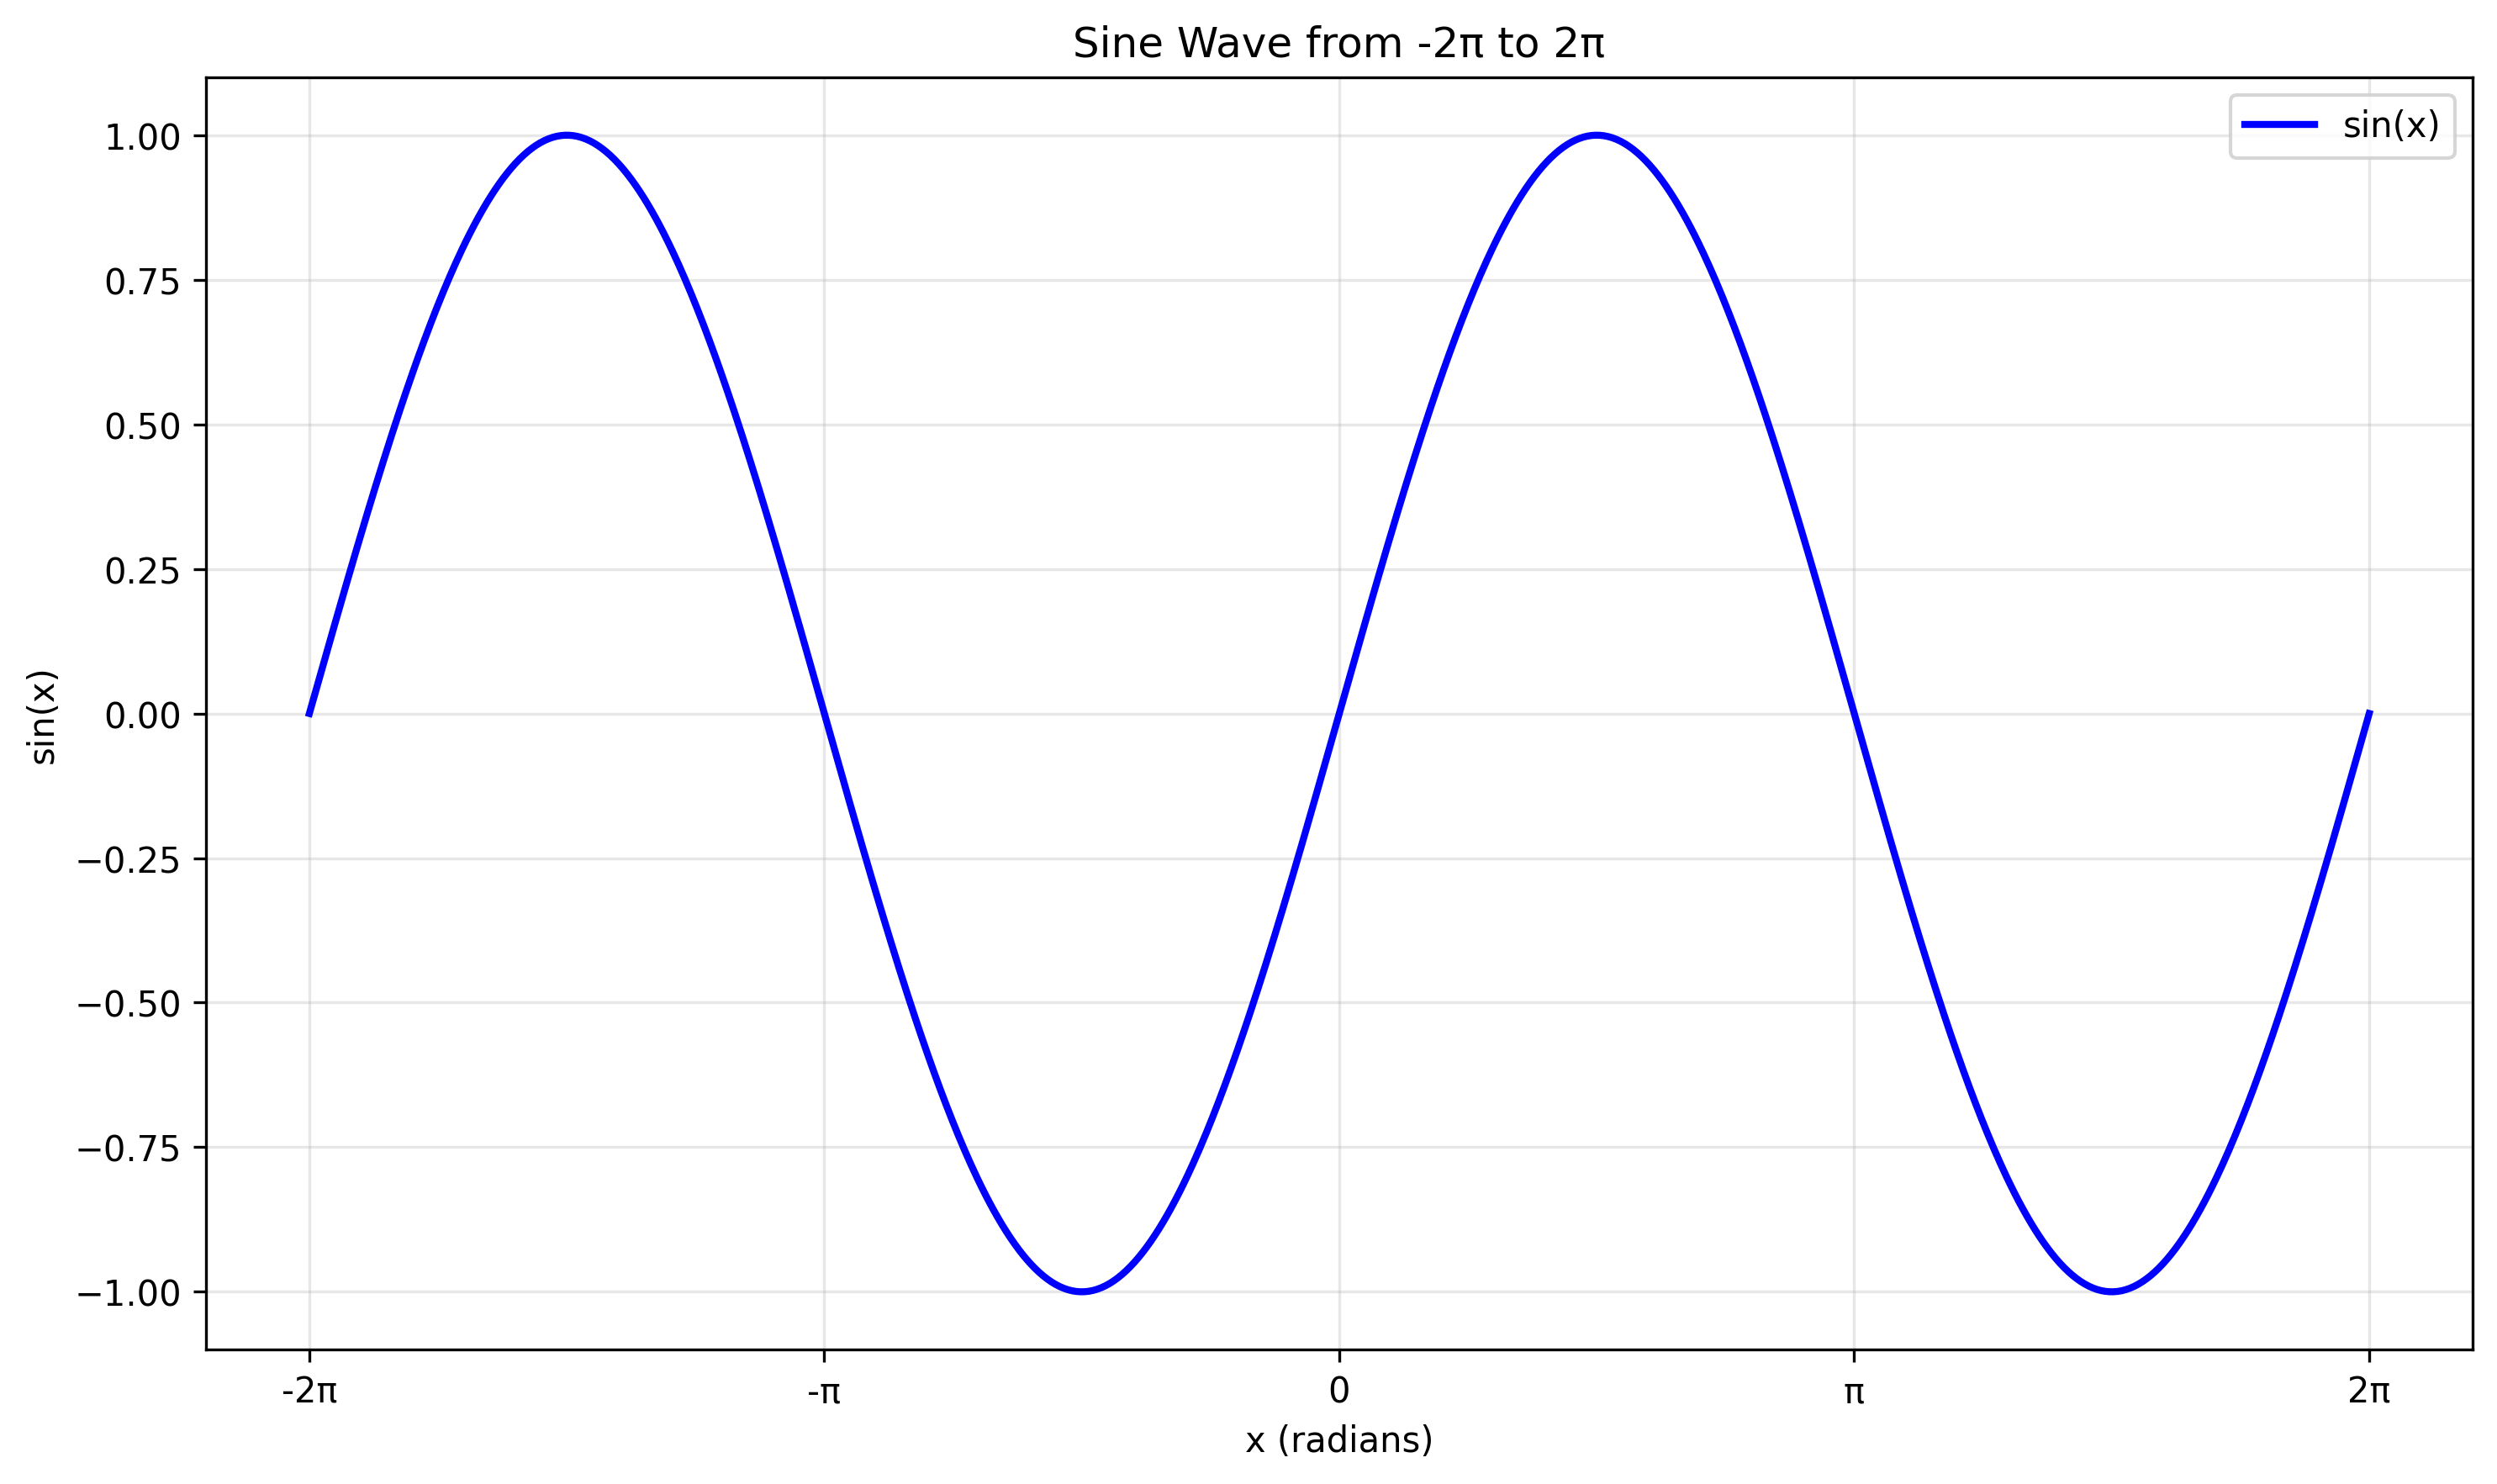


Final Summary:
The sine wave plot was successfully generated and saved as `sine_wave.png` since the required `numpy` and `matplotlib` libraries were pre-installed. Subsequent errors arose from unnecessary `pip` installation attempts conflicting with macOS PEP 668 protections and code execution formatting issues, not the plotting logic itself. Future package installations should utilize virtual environments or the `--user` flag to bypass externally-managed-environment restrictions.


In [15]:
# Requirements:
# !pip install matplotlib numpy pyautogen

from autogen import AssistantAgent, UserProxyAgent
from autogen.coding import LocalCommandLineCodeExecutor

# Step 2: Create assistant agent
assistant = AssistantAgent(
    name="assistant",
    system_message="You are a helpful assistant who writes and explains Python code clearly.",
    llm_config=llm_config
)

# Step 3: Create user proxy agent
user_proxy = UserProxyAgent(
    name="user_proxy",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=5,
    code_execution_config={
        "executor": LocalCommandLineCodeExecutor(work_dir="coding", timeout=30),
    },
)

# Step 4: Start task
chat_result = user_proxy.initiate_chat(
    recipient=assistant,
    message="Plot a sine wave using matplotlib from -2π to 2π and save the plot as sine_wave.png.",
    max_turns=12,
    summary_method="reflection_with_llm"
)

# Step 5: Display image
from IPython.display import Image, display
import os

image_path = "coding/sine_wave.png"
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print("Plot not found.")

# Step 6: Print summary
print("\nFinal Summary:")
print(chat_result.summary)

### Human-in-the-Loop

AG2 supports human-in-the-loop workflows so agents can pause for human review during important decisions.

Useful for:
- Critical judgment calls  
- High-stakes outcomes  
- Compliance and oversight  
- QA and validation  

Control behavior with `human_input_mode`:
- `ALWAYS`: ask for human input every turn  
- `NEVER`: fully autonomous  
- `TERMINATE`: ask only at termination points  

`UserProxyAgent` is the built-in option for this pattern (defaults to `ALWAYS`) and can execute code.  
Use code execution carefully.

##### Example: Bug Triage Bot

A `ConversableAgent` triages bugs (`escalate`, `close`, or `medium`) and asks a human to confirm or override each decision before finalizing.

Try replies like:
- Confirm: `"Yes, escalate it."`, `"Closing this makes sense."`
- Override: `"Mark this high priority instead."`, `"Keep this open."`
- Clarify: `"Why low priority?"`, `"Explain your reasoning."`

Type `exit` anytime to stop.

In [16]:
from autogen import ConversableAgent
import random

# Step 2: Define system message
triage_system_message = """
You are a bug triage assistant. You will be given bug report summaries.

For each bug:
- If it is urgent (e.g., 'crash', 'security', or 'data loss' is mentioned), escalate it and ask the human agent for confirmation.
- If it seems minor (e.g., cosmetic, typo), suggest closing it but still ask for human review.
- Otherwise, classify it as medium priority and ask the human for review.

Once all bugs are processed, summarize what was escalated, closed, or marked as medium priority.
End by saying: "You can type exit to finish."
"""

# Step 3: Create assistant agent
triage_bot = ConversableAgent(
    name="triage_bot",
    system_message=triage_system_message,
    llm_config=llm_config
)

# Step 4: Create human agent
human = ConversableAgent(
    name="human",
    human_input_mode="ALWAYS",
)

# Step 5: Generate sample bugs
BUGS = [
    "App crashes when opening user profile.",
    "Minor UI misalignment on settings page.",
    "Password reset email not sent consistently.",
    "Typo in the About Us footer text.",
    "Database connection timeout under heavy load.",
    "Login form allows SQL injection attack.",
]

random.shuffle(BUGS)
selected_bugs = BUGS[:3]

# Step 6: Format prompt
initial_prompt = (
    "Please triage the following bug reports one by one:\n\n" +
    "\n".join([f"{i+1}. {bug}" for i, bug in enumerate(selected_bugs)])
)

# Step 7: Start conversation
human.initiate_chat(
    recipient=triage_bot,
    message=initial_prompt,
)

human (to triage_bot):

Please triage the following bug reports one by one:

1. Typo in the About Us footer text.
2. Minor UI misalignment on settings page.
3. Database connection timeout under heavy load.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
triage_bot (to human):

**Bug 1: Typo in the About Us footer text.**
- **Classification:** Minor (Cosmetic/Typo)
- **Action:** I suggest closing this bug.
- **Request:** Please review this suggestion for human approval.

**Bug 2: Minor UI misalignment on settings page.**
- **Classification:** Minor (Cosmetic/UI)
- **Action:** I suggest closing this bug.
- **Request:** Please review this suggestion for human approval.

**Bug 3: Database connection timeout under heavy load.**
- **Classification:** Medium Priority
- **Action:** I classify this as medium priority.
- **Request:** Please review this classification for human approval.

***

**Summary of Triage:**
- **Escalated (Ur

ChatResult(chat_id=245478563737637303664987389209458045736, chat_history=[{'content': 'Please triage the following bug reports one by one:\n\n1. Typo in the About Us footer text.\n2. Minor UI misalignment on settings page.\n3. Database connection timeout under heavy load.', 'role': 'assistant', 'name': 'human'}, {'content': '**Bug 1: Typo in the About Us footer text.**\n- **Classification:** Minor (Cosmetic/Typo)\n- **Action:** I suggest closing this bug.\n- **Request:** Please review this suggestion for human approval.\n\n**Bug 2: Minor UI misalignment on settings page.**\n- **Classification:** Minor (Cosmetic/UI)\n- **Action:** I suggest closing this bug.\n- **Request:** Please review this suggestion for human approval.\n\n**Bug 3: Database connection timeout under heavy load.**\n- **Classification:** Medium Priority\n- **Action:** I classify this as medium priority.\n- **Request:** Please review this classification for human approval.\n\n***\n\n**Summary of Triage:**\n- **Escalated 

### Agent Orchestration & Multi-Agent Systems in AG2

AG2 supports **agent orchestration**, where multiple specialized agents collaborate while a manager controls flow.

##### Why use multi-agent systems?
- Split responsibilities across role-based agents  
- Use built-in orchestration patterns (`auto`, `round_robin`, `manual`, etc.)  
- Let agents refine each other’s outputs  
- Add humans for oversight and approvals  

##### Common orchestration patterns
- **Two-agent chat**: direct back-and-forth  
- **Sequential chat**: one agent’s output feeds the next  
- **Group chat**: multi-agent discussion with speaker selection logic  
- **Nested chat**: reusable sub-conversations  

### `GroupChat` and `GroupChatManager`

##### `GroupChat`
Defines:
- participating agents  
- how next speaker is chosen:
  - `"auto"` (LLM chooses)
  - `"round_robin"` (fixed order)
  - `"manual"` (human chooses)
  - `"random"` (random order)

##### `GroupChatManager`
Handles:
- message routing between agents  
- stop logic (termination condition or turn limit)  
- enforcement of selected speaker pattern  

##### Flow
1. Conversation starts (often by a user/teacher agent)  
2. Manager selects next speaker via pattern  
3. Agents respond by role  
4. Chat ends on stop condition (for example `"DONE"`) or max turns  

This pattern is useful for lesson planning, research workflows, and multi-perspective decision-making.

Docs: https://docs.ag2.ai/latest/docs/user-guide/advanced-concepts/orchestration/group-chat/introduction/

##### Example: Lesson planning
A teacher agent works with planner and reviewer agents in `GroupChat`.  
`is_termination_msg` can end the workflow when teacher replies `"DONE!"`.

In [17]:
from autogen import ConversableAgent, GroupChat, GroupChatManager

# System messages
planner_message = "Create a short lesson plan for 4th graders."
reviewer_message = "Review a plan and suggest up to 3 brief edits."
teacher_message = "Suggest a topic and reply DONE when satisfied."

# Create agents
lesson_planner = ConversableAgent(
    name="planner_agent",
    system_message=planner_message,
    description="Makes lesson plans.",
    llm_config=llm_config
)

lesson_reviewer = ConversableAgent(
    name="reviewer_agent",
    system_message=reviewer_message,
    description="Reviews lesson plans and suggests edits.",
    llm_config=llm_config
)

teacher = ConversableAgent(
    name="teacher_agent",
    system_message=teacher_message,
    llm_config=llm_config,
    is_termination_msg=lambda x: "DONE" in (x.get("content", "") or "").upper()
)

# Create group chat
groupchat = GroupChat(
    agents=[teacher, lesson_planner, lesson_reviewer],
    speaker_selection_method="auto"
)

# Create manager
manager = GroupChatManager(
    name="group_manager",
    groupchat=groupchat,
    llm_config=llm_config
)

# Start chat
teacher.initiate_chat(
    recipient=manager,
    message="Make a simple lesson about the moon.",
    max_turns=6,
    summary_method="reflection_with_llm"
)

teacher_agent (to group_manager):

Make a simple lesson about the moon.

--------------------------------------------------------------------------------

Next speaker: teacher_agent


>>>>>>>> USING AUTO REPLY...
teacher_agent (to group_manager):

**Topic: The Moon**

**Simple Lesson:**

1.  **What is the Moon?**
    The Moon is Earth's only natural satellite. It orbits around our planet.

2.  **Where does its light come from?**
    The Moon does not make its own light. It shines because it reflects light from the Sun.

3.  **Why does it change shape?**
    As the Moon orbits Earth, we see different parts of it lit up. These are called phases (New Moon, Crescent, Half, Full, etc.).

4.  **What does it do to Earth?**
    The Moon's gravity pulls on Earth's oceans, causing the tides to go in and out.

DONE

--------------------------------------------------------------------------------

Next speaker: planner_agent


>>>>>>>> USING AUTO REPLY...
planner_agent (to group_manager):

Here i

ChatResult(chat_id=110522679069356826788774970479754894735, chat_history=[{'content': 'Make a simple lesson about the moon.', 'role': 'assistant', 'name': 'teacher_agent'}, {'content': "**Topic: The Moon**\n\n**Simple Lesson:**\n\n1.  **What is the Moon?**\n    The Moon is Earth's only natural satellite. It orbits around our planet.\n\n2.  **Where does its light come from?**\n    The Moon does not make its own light. It shines because it reflects light from the Sun.\n\n3.  **Why does it change shape?**\n    As the Moon orbits Earth, we see different parts of it lit up. These are called phases (New Moon, Crescent, Half, Full, etc.).\n\n4.  **What does it do to Earth?**\n    The Moon's gravity pulls on Earth's oceans, causing the tides to go in and out.\n\nDONE", 'role': 'assistant', 'name': 'teacher_agent'}, {'content': 'Here is a structured lesson plan based on the content you provided, designed for a 4th-grade science class.\n\n# **Lesson Plan: Exploring the Moon**\n**Grade Level:** 4

##### Tools and Extensions

Tools let AG2 agents go beyond text by enabling them to:
- execute code  
- call APIs  
- perform calculations  
- query databases  
- create visualizations  

They make agents far more useful by connecting them to external data and capabilities.  
Now let’s see how to integrate tools into AG2 agents.

In [18]:
from autogen import ConversableAgent, register_function
from typing import Annotated

# Step 2: Define function
def is_prime(n: Annotated[int, "Positive integer"]) -> str:
    if n < 2:
        return "No"
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return "No"
    return "Yes"

# Step 3: Create agents
math_asker = ConversableAgent(
    name="math_asker",
    system_message="Ask whether a number is prime.",
    llm_config=llm_config
)

math_checker = ConversableAgent(
    name="math_checker",
    human_input_mode="NEVER",
    llm_config=llm_config
)

# Step 4: Register function
register_function(
    is_prime,
    caller=math_asker,
    executor=math_checker,
    description="Check if a number is prime. Returns Yes or No."
)

# Step 5: Start conversation
math_checker.initiate_chat(
    recipient=math_asker,
    message="Is 72 a prime number?",
    max_turns=2
)

math_checker (to math_asker):

Is 72 a prime number?

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
math_asker (to math_checker):


***** Suggested tool call (call_2a28347579f546d79e7b3759): is_prime *****
Arguments: 
{"n": 72}
*************************************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION is_prime...
Call ID: call_2a28347579f546d79e7b3759
Input arguments: {'n': 72}

>>>>>>>> EXECUTED FUNCTION is_prime...
Call ID: call_2a28347579f546d79e7b3759
Input arguments: {'n': 72}
Output:
No
math_checker (to math_asker):

***** Response from calling tool (call_2a28347579f546d79e7b3759) *****
No
**********************************************************************

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
math_asker (to math_checker):

No, 72 i

ChatResult(chat_id=45588095902127880164153004688789153149, chat_history=[{'content': 'Is 72 a prime number?', 'role': 'assistant', 'name': 'math_checker'}, {'content': '', 'tool_calls': [{'id': 'call_2a28347579f546d79e7b3759', 'function': {'arguments': '{"n": 72}', 'name': 'is_prime'}, 'type': 'function', 'index': 0}], 'role': 'assistant'}, {'content': 'No', 'tool_responses': [{'tool_call_id': 'call_2a28347579f546d79e7b3759', 'role': 'tool', 'content': 'No'}], 'role': 'tool', 'name': 'math_checker'}, {'content': 'No, 72 is not a prime number. A prime number is a number greater than 1 that has no positive divisors other than 1 and itself. Since 72 can be divided by numbers other than 1 and 72 (for example, 2, 3, 4, 6, 8, 9, 12, 18, 24, 36), it is not prime.', 'role': 'user', 'name': 'math_asker'}], summary='No, 72 is not a prime number. A prime number is a number greater than 1 that has no positive divisors other than 1 and itself. Since 72 can be divided by numbers other than 1 and 72 

##### What is `register_function(...)`?

In AG2, `register_function(...)` exposes a Python function as a tool so one agent can request it and another agent can execute it.

**Why use it**

- Add capabilities beyond text generation  
- Let agents solve tasks via function execution  
- Support caller–executor collaboration patterns  

**Parameters**
- `function`: Python function to expose  
- `caller`: agent that requests the tool  
- `executor`: agent that runs it  
- `description` *(optional)*: helps the LLM decide when to use it  

**Example**
```python
register_function(
    is_prime,
    caller=math_asker,
    executor=math_checker,
    description="Check if a number is prime. Returns Yes or No."
)
```

##### Structured Outputs

Structured outputs make agent responses consistent and validated using Pydantic schemas.

Why it matters:
- **Data validation**: stable response format  
- **API integration**: reliable data exchange  
- **Quality assurance**: fewer malformed outputs  
- **Type safety**: explicit data contracts  

In AG2, define a Pydantic model and pass it via `response_format` in `LLMConfig`:

```python
class ResponseModel(BaseModel):
    name: str
    status: str

llm_config = LLMConfig(
    api_type="openai",
    model="gpt-4o-mini",
    response_format=ResponseModel
)
```

With this setup, AG2 requests structured JSON, then parses and validates it automatically, which is key for robust automation and downstream systems.

In [19]:
from pydantic import BaseModel
from autogen import ConversableAgent

# Define structured output model
class TicketSummary(BaseModel):
    customer_name: str
    issue_type: str
    urgency_level: str
    recommended_action: str

# Create agent
support_agent = ConversableAgent(
    name="support_agent",
    system_message=(
        "You are a support assistant. Summarize a customer ticket using:"
        "\n- customer_name"
        "\n- issue_type (e.g. login issue, billing problem, bug report)"
        "\n- urgency_level (Low, Medium, High)"
        "\n- recommended_action"
    ),
    llm_config=llm_config
)

# Start conversation
support_agent.initiate_chat(
    recipient=support_agent,
    message="Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.",
    max_turns=1
)

support_agent (to support_agent):

Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.

--------------------------------------------------------------------------------

>>>>>>>> USING AUTO REPLY...
support_agent (to support_agent):

- **customer_name**: John Doe
- **issue_type**: Login Issue (Password Reset)
- **urgency_level**: High
- **recommended_action**: Escalate to priority support for immediate manual password reset or temporary access link.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (5a9fce2c-7eee-4725-85c3-82396900a4eb): Maximum turns (1) reached


ChatResult(chat_id=299616833334830222774857007655359613338, chat_history=[{'content': 'Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.', 'role': 'assistant', 'name': 'support_agent'}, {'content': 'Ticket: John Doe is unable to reset his password and has an important meeting in 30 minutes.', 'role': 'user', 'name': 'support_agent'}, {'content': '- **customer_name**: John Doe\n- **issue_type**: Login Issue (Password Reset)\n- **urgency_level**: High\n- **recommended_action**: Escalate to priority support for immediate manual password reset or temporary access link.', 'role': 'assistant', 'name': 'support_agent'}, {'content': '- **customer_name**: John Doe\n- **issue_type**: Login Issue (Password Reset)\n- **urgency_level**: High\n- **recommended_action**: Escalate to priority support for immediate manual password reset or temporary access link.', 'role': 'user', 'name': 'support_agent'}], summary='- **customer_name**: John Doe\n- **issue_type*

### Best Practices

##### Configuration & security
- Keep API keys in environment variables, never in code  
- Use config lists for production fallback models  
- Set temperature by goal (`0.0` deterministic, higher for creativity)  
- Add rate limiting and error handling  

##### Agent design
- Write clear system messages (role, limits, behavior)  
- Set `max_consecutive_auto_reply` to avoid loops  
- Pick the right `human_input_mode` for your workflow  
- Prefer specialized agents over one general-purpose agent  

##### Human-in-the-loop (HITL)
- Use HITL for high-stakes decisions  
- Define explicit escalation rules (risk/amount thresholds)  
- Provide enough context for human reviewers  
- Log interventions for traceability  

##### Multi-agent orchestration
- Define clear handoffs and workflow steps  
- Use `GroupChat` for collaborative tasks  
- Add termination rules to prevent endless chats  
- Monitor conversation quality and intervention points  

##### Tools & integration
- Build focused, single-purpose tools  
- Validate tool inputs/outputs and handle failures  
- Document each tool so agents know when to use it  

##### Structured outputs
- Use Pydantic models for schema validation  
- Keep schemas explicit and stable  
- Return meaningful validation errors  
- Version schemas for backward compatibility